In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,roc_auc_score
url ="https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv" 
df=pd.read_csv(url)
df.info()

In [ ]:
df['TotalCharges']=df['TotalCharges'].str.strip().replace("", 0)
df['TotalCharges']=df['TotalCharges'].astype('float64')# converting to float datatype

In [ ]:
df['TotalCharges'].min()# confirming the minimum charges are 0
df['MonthlyCharges'].min()# minimum 18.25 good.

df['SeniorCitizen'].unique() # 0 and 1 values
df['gender']=df['gender'].replace(["Male","Female"],[0,1])
df['Partner']=df['Partner'].replace(["No","Yes"],[0,1])

df['gender']=df['gender'].astype('int64')
df['Partner']=df['Partner'].astype('int64')

df['Dependents']=df['Dependents'].replace(["No","Yes"],[0,1])
df['Dependents']=df['Dependents'].astype('int64')

df['PhoneService']=df['PhoneService'].replace(["No","Yes"],[0,1])
df['PhoneService']=df['PhoneService'].astype('int64')

#The coulumn multiplelines has three unique strings since No phone service directly means that the person has no multiple line we merge them as a single column
df['MultipleLines']=df['MultipleLines'].replace(["No phone service","No","Yes"],[0,0,1])
df['MultipleLines']=df['MultipleLines'].astype('int64')

dummies=pd.get_dummies(df['InternetService'],drop_first=True) # 3 unique values 
df=pd.concat([df,dummies],axis=1)
df=df.drop(columns='InternetService')
df=df.rename(columns={'No':'InternetService_No','Fiber optic':'InternetService_FiberOptic'})

df['OnlineBackup']=df['OnlineBackup'].replace(['No','No internet service', 'Yes'],[0,0,1])
df['OnlineBackup']=df['OnlineBackup'].astype('int64')

df['OnlineSecurity']=df['OnlineSecurity'].replace(['No','No internet service', 'Yes'],[0,0,1])
df['OnlineSecurity']=df['OnlineSecurity'].astype('int64')

df['DeviceProtection']=df['DeviceProtection'].replace(['No','No internet service', 'Yes'],[0,0,1])
df['DeviceProtection']=df['DeviceProtection'].astype('int64')

df['TechSupport']=df['TechSupport'].replace(['No','No internet service', 'Yes'],[0,0,1])
df['TechSupport']=df['TechSupport'].astype('int64')

df['StreamingMovies']=df['StreamingMovies'].replace(['No','No internet service', 'Yes'],[0,0,1])
df['StreamingMovies']=df['StreamingMovies'].astype('int64')

df['StreamingTV']=df['StreamingTV'].replace(['No','No internet service', 'Yes'],[0,0,1])
df['StreamingTV']=df['StreamingTV'].astype('int64')

dummies=pd.get_dummies(df['Contract'],drop_first=True)
df=pd.concat([df,dummies],axis=1)
df=df.drop(columns='Contract')
df = df.rename(columns={'One year': 'Contract_OneYear','Two year': 'Contract_TwoYear'})

df['PaperlessBilling']=df['PaperlessBilling'].replace(["No","Yes"],[0,1])
df['PaperlessBilling']=df['PaperlessBilling'].astype('int64')

df['PaymentMethod'].unique()
dummies=pd.get_dummies(df['PaymentMethod'],drop_first=True)
df=pd.concat([df,dummies],axis=1)
df=df.drop(columns='PaymentMethod')
df = df.rename(columns={'Credit card (automatic)': 'PaymentMethod_CreditCard','Electronic check': 'PaymentMethod_ElectronicCheck','Mailed check': 'PaymentMethod_MailedCheck'})
df['Churn']=df['Churn'].replace(["No","Yes"],[0,1])
df['Churn']=df['Churn'].astype('int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customerID                     7043 non-null   str    
 1   gender                         7043 non-null   int64  
 2   SeniorCitizen                  7043 non-null   int64  
 3   Partner                        7043 non-null   int64  
 4   Dependents                     7043 non-null   int64  
 5   tenure                         7043 non-null   int64  
 6   PhoneService                   7043 non-null   int64  
 7   MultipleLines                  7043 non-null   int64  
 8   OnlineSecurity                 7043 non-null   int64  
 9   OnlineBackup                   7043 non-null   int64  
 10  DeviceProtection               7043 non-null   int64  
 11  TechSupport                    7043 non-null   int64  
 12  StreamingTV                    7043 non-null   int64  
 13 

In [ ]:

df['Churn'].value_counts(normalize=True) # 0-73.4 and 1-26.5 Unbalanced
#Confirming the totalcharges=tenure*MonthlyCharges
df['calculatedcharges']=df['tenure']*df['MonthlyCharges']
df[['calculatedcharges','TotalCharges']].corr()# 0.9996 almost perfect match


,calculatedcharges,TotalCharges
calculatedcharges,1.000000,0.999561
TotalCharges,0.999561,1.000000


In [ ]:
#Choosing columns for the models to avoid useless and data leakage columns
X_reg=df.drop(columns=['customerID','MonthlyCharges','TotalCharges','Churn','calculatedcharges'])
Y_reg=df['MonthlyCharges']

X_clf=df.drop(columns=['customerID','Churn','calculatedcharges'])
Y_clf=df['Churn']

The mse values are  1.1052104112090688
The r2 values are  0.998779278341754


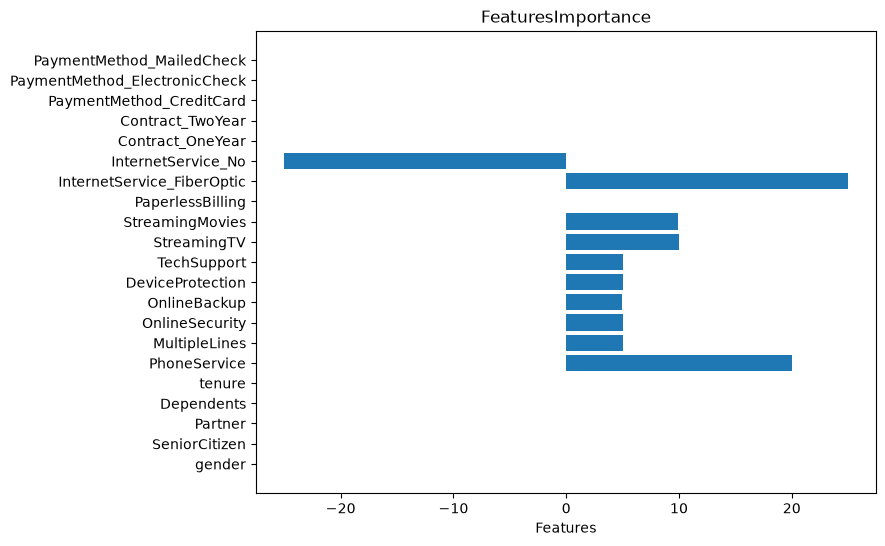

In [ ]:
#Splitting the data and appplying linear regression on it
X_train_reg,X_test_reg,Y_train_reg,Y_test_reg=train_test_split(X_reg,Y_reg,test_size=0.2,random_state=42)
X_train_clf,X_test_clf,Y_train_clf,Y_test_clf=train_test_split(X_clf,Y_clf,test_size=0.2,stratify=Y_clf,random_state=42)

model_reg=LinearRegression()
model_reg.fit(X_train_reg,Y_train_reg)
Y_predict_reg=model_reg.predict(X_test_reg)

mse=mean_squared_error(Y_test_reg,Y_predict_reg)
r2=r2_score(Y_test_reg,Y_predict_reg)
print("The mse values are " , mse)
print("The r2 values are ", r2)

coef_df=pd.DataFrame({'feature':X_train_reg.columns,'coefficient':model_reg.coef_})
coef_df.sort_values('coefficient',key=abs,ascending=False)

plt.figure(figsize=(8,6))
plt.barh(coef_df['feature'],coef_df['coefficient'])
plt.xlabel("Features")
plt.title("FeaturesImportance")
plt.show()


In [ ]:
#Model without any balanced weight or unscaled data
model_clf_baseline = LogisticRegression()
model_clf_baseline.fit(X_train_clf, Y_train_clf)
Y_pred_clf_baseline = model_clf_baseline.predict(X_test_clf)
print(classification_report(Y_test_clf, Y_pred_clf_baseline))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



c:\Users\abdul\OneDrive\Desktop\Python\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Model with scaled data but no balanced weight
scaler = StandardScaler()
scaler_train_X_clf = scaler.fit_transform(X_train_clf)
scaler_test_X_clf = scaler.transform(X_test_clf)

model_clf_scaled = LogisticRegression()
model_clf_scaled.fit(scaler_train_X_clf, Y_train_clf)
Y_pred_clf_scaled = model_clf_scaled.predict(scaler_test_X_clf)
print(classification_report(Y_test_clf, Y_pred_clf_scaled))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
#MOdel with scaled and balanced weight, the recall increased in this model
model_clf=LogisticRegression(class_weight='balanced')
scaler=StandardScaler()
scaler_train_X_clf=scaler.fit_transform(X_train_clf)
scaler_test_X_clf=scaler.transform(X_test_clf)

model_clf.fit(scaler_train_X_clf,Y_train_clf)
Y_pred_clf=model_clf.predict(scaler_test_X_clf)
print(classification_report(Y_test_clf,Y_pred_clf))

Y_proba_clf = model_clf.predict_proba(scaler_test_X_clf)[:, 1]#probability of class 1 (churn)
auc = roc_auc_score(Y_test_clf, Y_proba_clf)
print("ROC-AUC:", auc)

coef_clf_df=pd.DataFrame({
    'feature':X_train_clf.columns,
    'coefficient':model_clf.coef_[0]
})
coef_clf_df.sort_values('coefficient', key=abs, ascending=False)

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



,feature,coefficient
4,tenure,-1.155638
14,MonthlyCharges,-0.955323
16,InternetService_FiberOptic,0.777051
17,InternetService_No,-0.661219
19,Contract_TwoYear,-0.616481
15,TotalCharges,0.488345
18,Contract_OneYear,-0.296230
12,StreamingMovies,0.272765
11,StreamingTV,0.260060
6,MultipleLines,0.195288


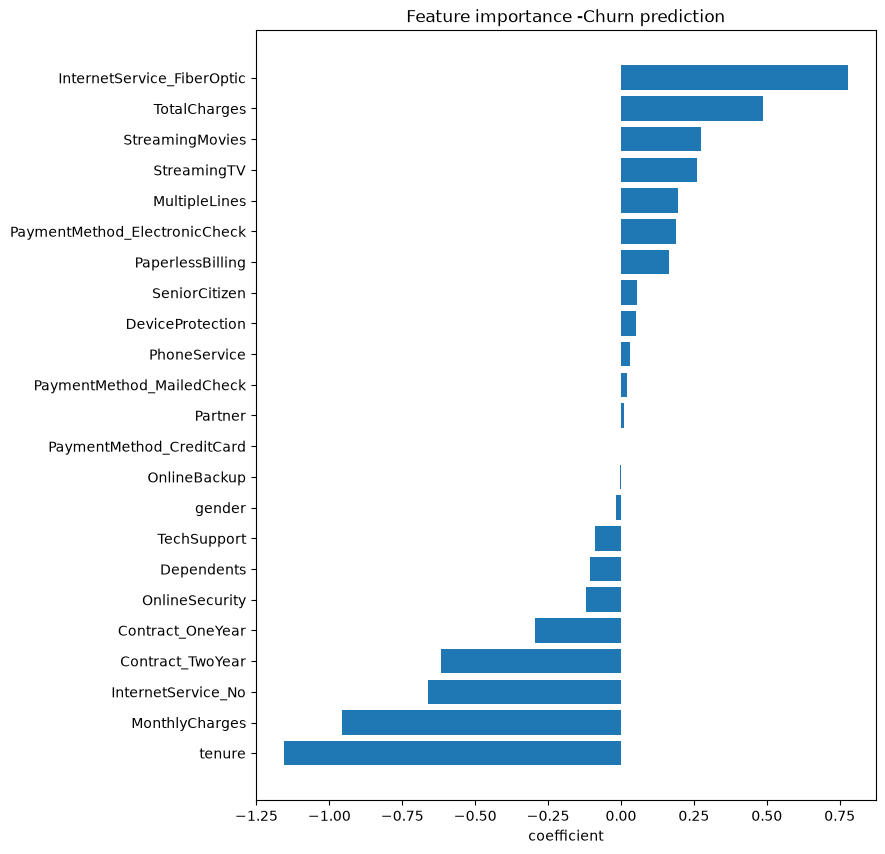

In [ ]:
plot_df=coef_clf_df.sort_values('coefficient')
plt.figure(figsize=(8,10))
plt.barh(plot_df['feature'],plot_df['coefficient'])
plt.xlabel('coefficient')
plt.title('Feature importance -Churn prediction')
plt.show()